In [ ]:
from itertools import product
from lib import LinearSVC, make_classification
import pandas as pd

#  Generate and save the files
dimensions = [100, 500, 800]
size = [10000, 30000, 50000]

for n,d in product(dimensions, size):
    X_train, X_test, y_train, y_test, a = make_classification(d, n, 100, 7)
    df_train = pd.DataFrame(X_train)
    df_train['label'] = y_train

    df_test = pd.DataFrame(X_test)
    df_test['label'] = y_test

    df_train.to_csv(f'../data/train_{n}_{d}.csv')
    df_test.to_csv(f'../data/test_{n}_{d}.csv')



In [ ]:
from lib import LinearSVC, make_classification
import time
import matplotlib.pyplot as plt
import pandas as pd

dimensions = [100, 500, 800]
size = [10000, 30000, 50000]
# We store the table here 
results = []
#  We use subplots to show the loss. So we save them in a map with tuples as the coordinate
loss_map = {}

for i, d in enumerate(dimensions):
    for j, n in enumerate(size):
        model = LinearSVC(random_state=42, lam=1.0/n, epochs=50)

        X_train, X_test, y_train, y_test, a = make_classification(d, n, 100, 7)
        #  Measure the time to train
        start = time.perf_counter()
        model.fit(X_train, y_train)
        end = time.perf_counter()

        elapsed = end - start
        y_pred = model.predict(X_test)
        accuracy = (y_pred == y_test).sum()/len(y_test)
        # Append to the table
        results.append([d, n, elapsed, accuracy, model.losses_[-1]])
        loss_map[(i, j)] = model.losses_

df = pd.DataFrame(results, columns=["d", "n", "time_sec", "accuracy", 'final_loss'])
df

,d,n,time_sec,accuracy,final_loss
0,100,10000,0.034099,0.988000,0.035951
1,100,30000,0.104421,0.989556,0.026146
2,100,50000,0.249173,0.992467,0.023627
3,500,10000,0.088479,0.966667,0.031469
4,500,30000,0.438220,0.981556,0.039442
5,500,50000,0.638684,0.985000,0.036227
6,800,10000,0.204196,0.943000,0.017320
7,800,30000,0.635784,0.977333,0.035838
8,800,50000,0.941190,0.981400,0.039131


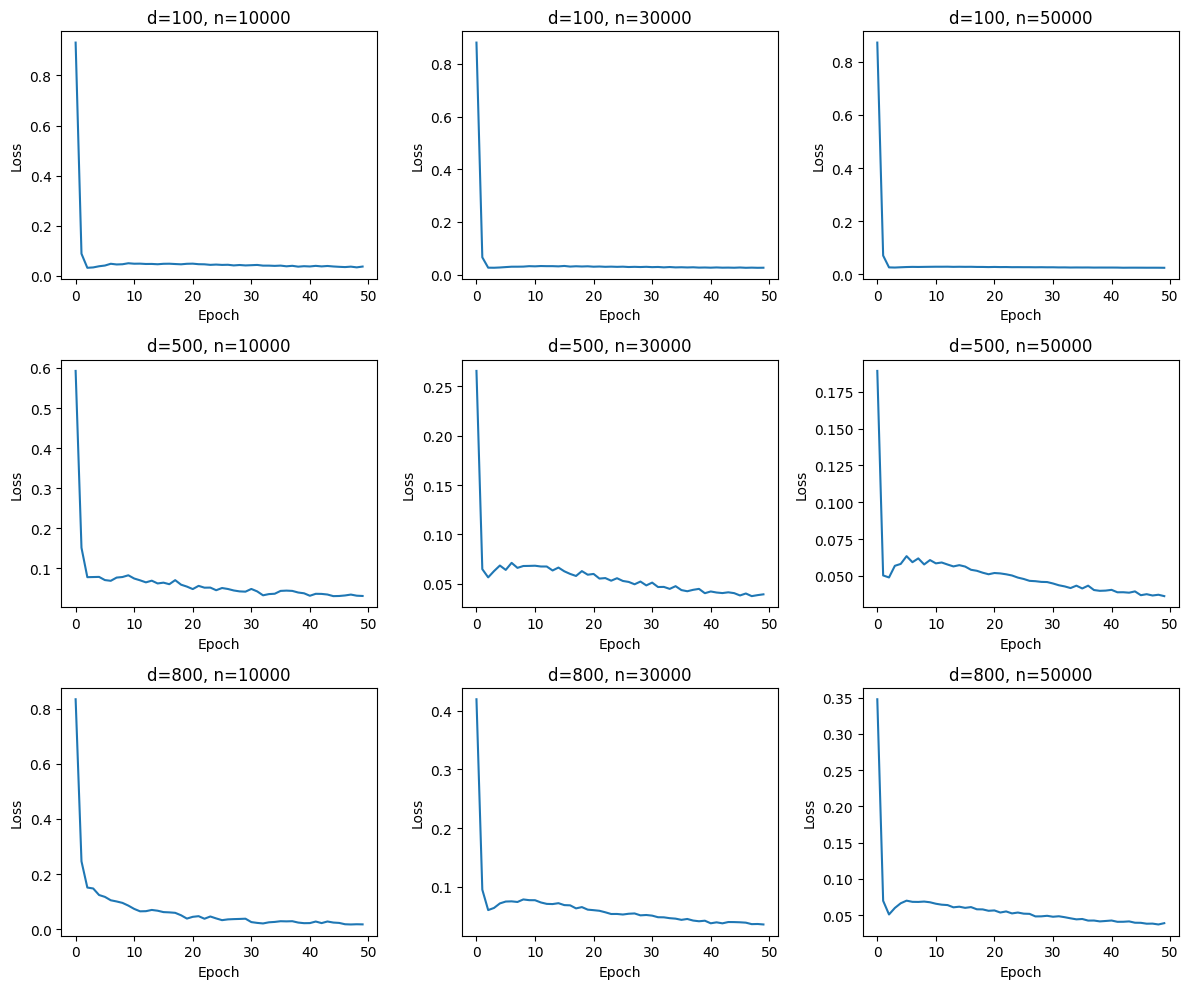

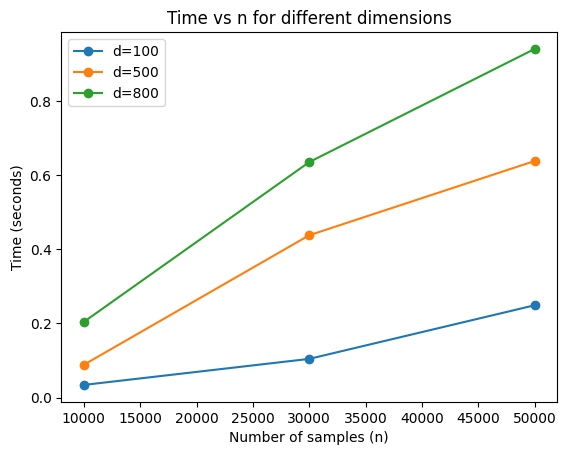

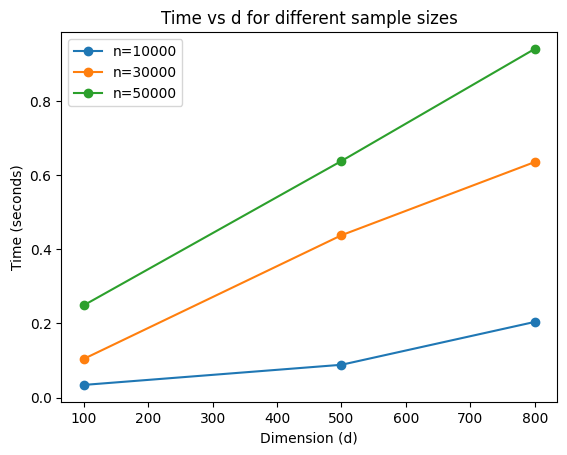

In [ ]:
#  Q3. Plot loss convergence in a subplot
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, d in enumerate(dimensions):
    for j, n in enumerate(size):
        axes[i, j].plot(loss_map[(i, j)])
        axes[i, j].set_title(f"d={d}, n={n}")
        axes[i, j].set_xlabel("Epoch")
        axes[i, j].set_ylabel("Loss")

plt.tight_layout()
plt.show()

#  For time cost, we can visulaize 2 plots
plt.figure()
#  Time cost vs n for each dimension
for d in dimensions:
    subset = df[df["d"] == d]
    plt.plot(subset["n"], subset["time_sec"], marker='o', label=f"d={d}")

plt.xlabel("Number of samples (n)")
plt.ylabel("Time (seconds)")
plt.title("Time vs n for different dimensions")
plt.legend()
plt.show()

#  Time cost vs d for each sample size
plt.figure()
for n in size:
    subset = df[df["n"] == n]
    plt.plot(subset["d"], subset["time_sec"], marker='o', label=f"n={n}")

plt.xlabel("Dimension (d)")
plt.ylabel("Time (seconds)")
plt.title("Time vs d for different sample sizes")
plt.legend()
plt.show()